In [6]:
import os

old = r"d:\VS codes\ML Coding\interference.py"
new = r"d:\VS codes\ML Coding\inference.py"

os.rename(old, new)
print(f"Renamed successfully!")
print(f"Exists now: {os.path.exists(new)}")

Renamed successfully!
Exists now: True


In [7]:
import sys
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# Add project root explicitly
sys.path.insert(0, r"d:\VS codes\ML Coding")

# Also add root so inference.py is found directly
import importlib.util

# Load inference.py manually from full path
spec = importlib.util.spec_from_file_location(
    "inference",
    r"d:\VS codes\ML Coding\inference.py"
)
inference_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(inference_module)

# Pull functions out of the module
preprocess_image       = inference_module.preprocess_image
postprocess_detections = inference_module.postprocess_detections
draw_detections_cv2    = inference_module.draw_detections_cv2
draw_stats_overlay     = inference_module.draw_stats_overlay
load_model_for_inference = inference_module.load_model_for_inference
run_on_image           = inference_module.run_on_image

import configs.config as cfg
from dataset.coco_dataset import LABEL_TO_NAME

device = torch.device(cfg.DEVICE)
print(f"Device  : {device}")
print(f"Imports : OK")

Device  : cpu
Imports : OK


In [8]:
# Load model with random weights (no checkpoint yet)
model = load_model_for_inference(
    checkpoint_path = None,
    device          = device,
)
print(f"Model loaded — eval mode: {not model.training}")

[Backbone] Built resnet50 + FPN
[Backbone] Output channels: 256
[Backbone] Pretrained: False
[Backbone] Frozen params: 24 | Trainable params: 45

[Detector] Model built successfully
[Detector] Backbone    : resnet50 + FPN
[Detector] Num classes : 7 (including background)
[Detector] Anchors     : 5 levels x 3 ratios = 15 anchor types
[Detector] ROI output  : 7x7 per proposal

  Model ready on cpu

Model loaded — eval mode: True


=== Preprocessing Test ===

Image file    : 000000000036.jpg
Original size : (640, 481)  (H, W)
Tensor shape  : torch.Size([3, 640, 481])
Tensor dtype  : torch.float32
Value range   : [-2.118, 2.640]
  (normalized — not [0,1] anymore, that's correct)


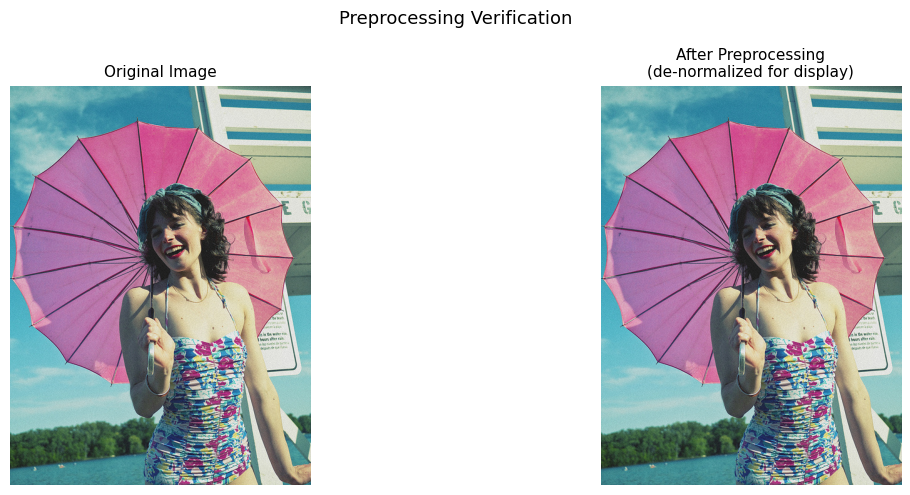

In [9]:
import os
from PIL import Image

# Pick any image from your dataset
img_dir   = cfg.TRAIN_IMG_DIR
img_name  = os.listdir(img_dir)[0]
img_path  = os.path.join(img_dir, img_name)

tensor, orig_size = preprocess_image(img_path)

print("=== Preprocessing Test ===\n")
print(f"Image file    : {img_name}")
print(f"Original size : {orig_size}  (H, W)")
print(f"Tensor shape  : {tensor.shape}")
print(f"Tensor dtype  : {tensor.dtype}")
print(f"Value range   : [{tensor.min():.3f}, {tensor.max():.3f}]")
print(f"  (normalized — not [0,1] anymore, that's correct)")

# Show original vs tensor side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
axes[0].imshow(np.array(Image.open(img_path)))
axes[0].set_title("Original Image", fontsize=11)
axes[0].axis("off")

# De-normalized for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
display = (tensor * std + mean).clamp(0,1).permute(1,2,0).numpy()
axes[1].imshow(display)
axes[1].set_title("After Preprocessing\n(de-normalized for display)",
                  fontsize=11)
axes[1].axis("off")

plt.suptitle("Preprocessing Verification", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Run inference with random weights
# Expect random/garbage detections — that's fine at this stage

tensor, orig_size = preprocess_image(img_path)
tensor = tensor.to(device)

with torch.no_grad():
    raw_output = model([tensor])

print("=== Raw Model Output ===\n")
print(f"Keys          : {list(raw_output[0].keys())}")
print(f"Num raw boxes : {len(raw_output[0]['boxes'])}")
print(f"Score range   : [{raw_output[0]['scores'].min():.3f}, "
      f"{raw_output[0]['scores'].max():.3f}]")

# Post-process
dets = postprocess_detections(
    raw_output[0],
    orig_size,
    score_thresh = 0.5,
    nms_thresh   = 0.4,
)

print(f"\n=== After Post-processing ===\n")
print(f"Detections kept : {len(dets['boxes'])}")
print(f"Classes found   : {set(dets['class_names'])}")

=== Raw Model Output ===

Keys          : ['boxes', 'labels', 'scores']
Num raw boxes : 27
Score range   : [0.069, 1.000]

=== After Post-processing ===

Detections kept : 18
Classes found   : {'person', 'motorcycle', 'bus'}


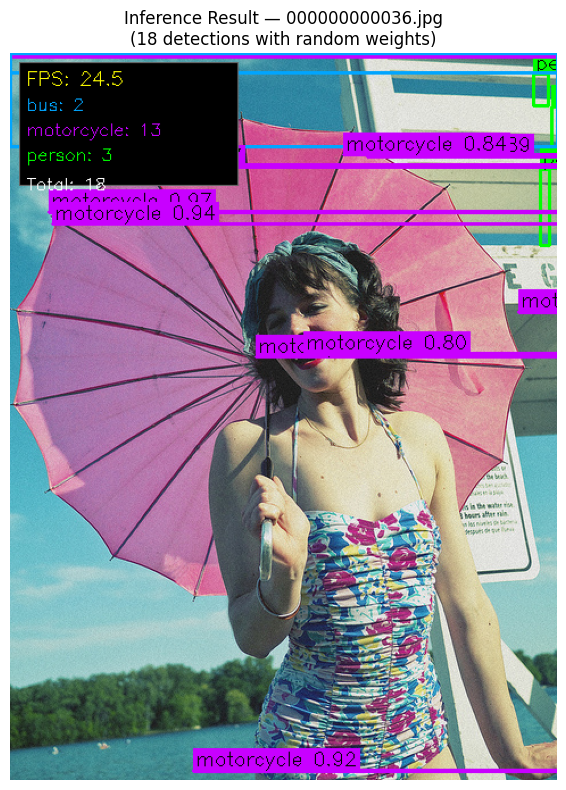


Detection details:
  [1] person          score=1.000  box=[466.7, 102.8, 474.8, 169.7]
  [2] person          score=1.000  box=[476.8, 47.2, 481.0, 92.5]
  [3] person          score=1.000  box=[460.9, 18.9, 473.3, 46.9]
  [4] bus             score=0.982  box=[0.0, 0.0, 481.0, 82.7]
  [5] motorcycle      score=0.975  box=[45.0, 98.4, 481.0, 98.7]
  [6] motorcycle      score=0.973  box=[60.6, 100.3, 481.0, 100.6]
  [7] motorcycle      score=0.967  box=[35.0, 139.6, 481.0, 140.4]
  [8] motorcycle      score=0.957  box=[447.8, 227.9, 481.0, 228.3]
  [9] motorcycle      score=0.942  box=[37.0, 150.3, 481.0, 150.7]
  [10] motorcycle      score=0.916  box=[161.8, 631.2, 481.0, 632.1]
  [11] motorcycle      score=0.913  box=[216.1, 267.5, 481.0, 268.0]
  [12] motorcycle      score=0.912  box=[0.0, 0.8, 481.0, 1.8]
  [13] motorcycle      score=0.894  box=[31.9, 0.1, 481.0, 0.2]
  [14] motorcycle      score=0.891  box=[314.6, 90.7, 481.0, 91.1]
  [15] motorcycle      score=0.845  box=[293.2, 89.

In [11]:
# Draw detections on real image
frame = cv2.imread(img_path)
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Draw (even if detections are garbage — testing the drawing code)
frame_bgr  = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
annotated  = draw_detections_cv2(frame_bgr, dets)
annotated  = draw_stats_overlay(annotated, dets, fps=24.5)
annotated  = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.title(f"Inference Result — {img_name}\n"
          f"({len(dets['boxes'])} detections "
          f"with random weights)", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"\nDetection details:")
for i, (name, score, box) in enumerate(zip(
    dets["class_names"],
    dets["scores"],
    dets["boxes"]
)):
    print(f"  [{i+1}] {name:<15} score={score:.3f}  "
          f"box={[round(x,1) for x in box.tolist()]}")

  Saved → outputs/test_inference.jpg
run_on_image() works!
Detections  : 18
Saved to    : outputs/test_inference.jpg
File exists : True


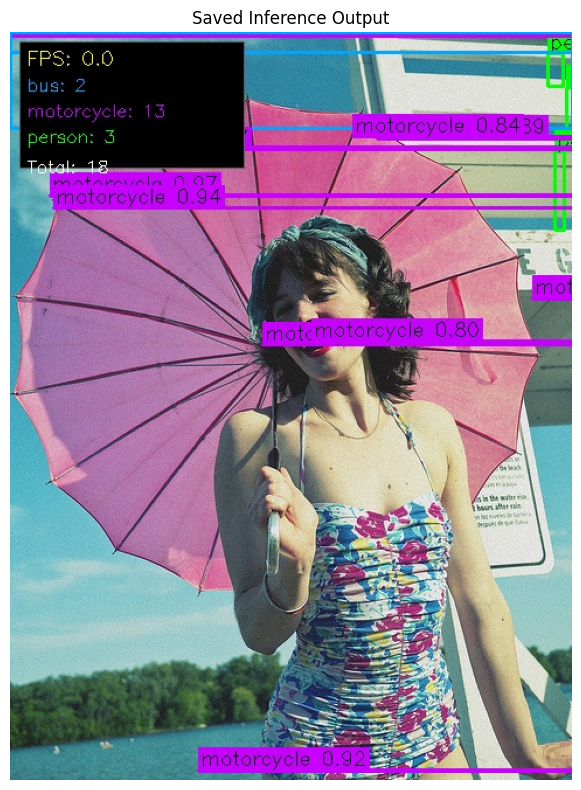

In [12]:
import os

os.makedirs("outputs", exist_ok=True)
save_path = "outputs/test_inference.jpg"

dets, annotated_frame = run_on_image(
    model        = model,
    image_path   = img_path,
    device       = device,
    score_thresh = 0.5,
    save_path    = save_path,
)

print(f"run_on_image() works!")
print(f"Detections  : {len(dets['boxes'])}")
print(f"Saved to    : {save_path}")
print(f"File exists : {os.path.exists(save_path)}")

# Display saved output
saved = cv2.imread(save_path)
saved = cv2.cvtColor(saved, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(saved)
plt.title("Saved Inference Output", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
checks = {}

# 1. Preprocessing works
t, s = preprocess_image(img_path)
checks["Preprocessing works"]          = t.shape[0] == 3
checks["Tensor is float32"]            = t.dtype == torch.float32
checks["Normalized correctly"]         = t.min().item() < 0

# 2. Model returns correct keys
with torch.no_grad():
    out = model([t.to(device)])
checks["Model returns boxes"]          = "boxes"  in out[0]
checks["Model returns labels"]         = "labels" in out[0]
checks["Model returns scores"]         = "scores" in out[0]

# 3. Postprocessing works
dets = postprocess_detections(
    out[0], s, score_thresh=0.5
)
checks["Postprocessing works"]         = isinstance(dets, dict)
checks["class_names in output"]        = "class_names" in dets

# 4. Scores above threshold
if len(dets["scores"]) > 0:
    checks["All scores above threshold"] = (
        dets["scores"] >= 0.5
    ).all().item()
else:
    checks["All scores above threshold"] = True

# 5. Saved file exists
checks["Output image saved"]           = os.path.exists(save_path)

# 6. Model is in eval mode
checks["Model in eval mode"]           = not model.training

print("=== Step 8 Checklist ===\n")
all_passed = True
for check, passed in checks.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {check}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("All checks passed — ready for Step 9 (Density Maps)!")
else:
    print("Fix the failing checks before moving on.")

=== Step 8 Checklist ===

  ✅  Preprocessing works
  ✅  Tensor is float32
  ✅  Normalized correctly
  ✅  Model returns boxes
  ✅  Model returns labels
  ✅  Model returns scores
  ✅  Postprocessing works
  ✅  class_names in output
  ✅  All scores above threshold
  ✅  Output image saved
  ✅  Model in eval mode

All checks passed — ready for Step 9 (Density Maps)!
